#### 1. Бизнес-цель для набора данных для решения задачи кластеризации

Цель: выделить «профили» машин, которые потенциально ориентированы на разные аудитории (семейные авто, спортивные, экономичные, комфорт-класс и тд.)

#### 2. Выполнить понижение размерности и визуализацию данных

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = pd.read_csv("car_price_prediction.csv", sep=",")
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [2]:
# Levy. Преобразование сбора. Заменяем (-) на 0
X['Levy'] = X['Levy'].fillna(0)
X['Levy'] = pd.to_numeric(X['Levy'], errors='coerce')
# Заполним пропуски медианой
X['Levy'] = X['Levy'].fillna(X['Levy'].median())

# Удаляем ID и Price
X = X.drop(columns=['ID', 'Price'])

# Leather interior. Заменим ответы Yes/No на цифры: Yes — 1, No — 0.
X['Leather interior'] = X['Leather interior'].map({'Yes': 1, 'No': 0})

# Engine volume + Turbo. Преобразование объема двигателя
# Извлекаем числовое значение и отдельно флаг Turbo
X['Turbo'] = X['Engine volume'].str.contains('Turbo').astype(int)
X['Engine volume'] = X['Engine volume'].str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Mileage. Преобразование пробега, убираем km, делаем int
X['Mileage'] = X['Mileage'].str.replace(r'\D+', '', regex=True).astype(int)

# Doors. Преобразование дверей, в сете все значения вида '02-Mar', имелось в виду 2-3, и вида ">5"
# Заменим такие данные на большее значение
X['Doors'] = X['Doors'].replace({
    '02-Mar': 3,
    '04-May': 5,
    '06-Jul': 6, 
    '>5': '5',
})
X['Doors'] = X['Doors'].astype(str).str.extract(r'(\d+)')[0].astype(int)

# Wheel. Есть 2 типа: Left wheel и Right-hand drive, заменим их бинарно
X['Wheel'] = X['Wheel'].map({'Left wheel': 0, 'Right-hand drive': 1})

# добавляем столбец с возрастом автомобиля
X['Age'] = 2025 - X['Prod. year']
# удляем признак Prod. year
X.drop(columns='Prod. year', inplace=True)

# Категориальные признаки: one-hot encoding
X = pd.get_dummies(X, drop_first=True)  # drop_first — чтобы избежать мультиколлинеарности

# Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

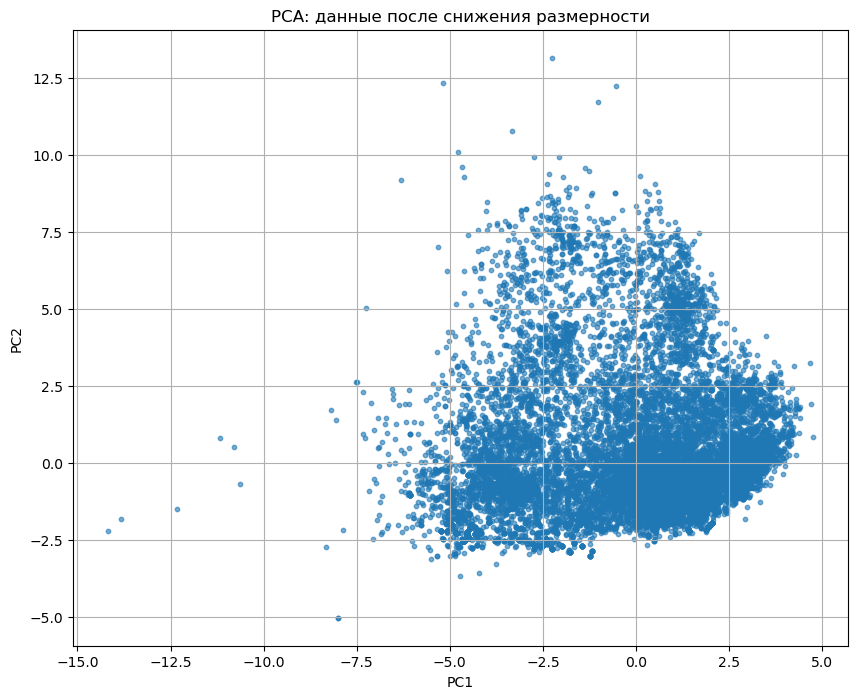

Объяснённая дисперсия: 0.55%


In [3]:
# Применяем PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=10)
plt.title('PCA: данные после снижения размерности')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# Вывод объяснённой дисперсии
print(f'Объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%}')

#### 3. Выполнить выбор количества кластеров на основе оценки инерции и коэффициента силуэта


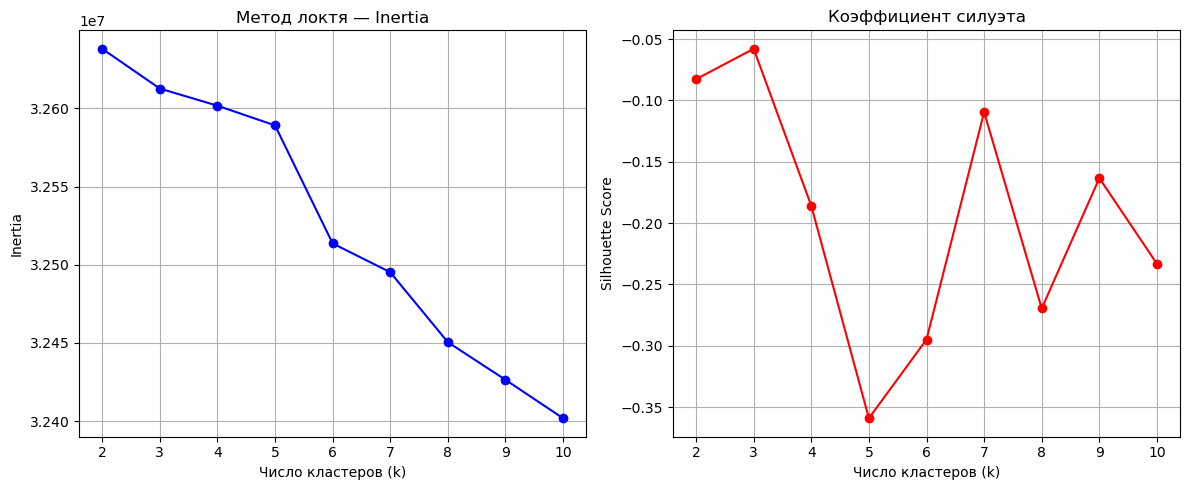

Наилучшее число кластеров по силуэту: 3


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Диапазон числа кластеров
K = range(2, 11)
inertias = []
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# График инерции (метод локтя)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bo-')
plt.title('Метод локтя — Inertia')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Inertia')
plt.grid(True)

# График силуэта
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'ro-')
plt.title('Коэффициент силуэта')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Вывод лучшего k по силуэту
best_k = K[np.argmax(silhouette_scores)]
print(f'Наилучшее число кластеров по силуэту: {best_k}')

#### 4. Выполнить кластерный анализ с применением иерархического и неиерархического алгоритма кластеризации

Неиерархический алгоритм (K-means)

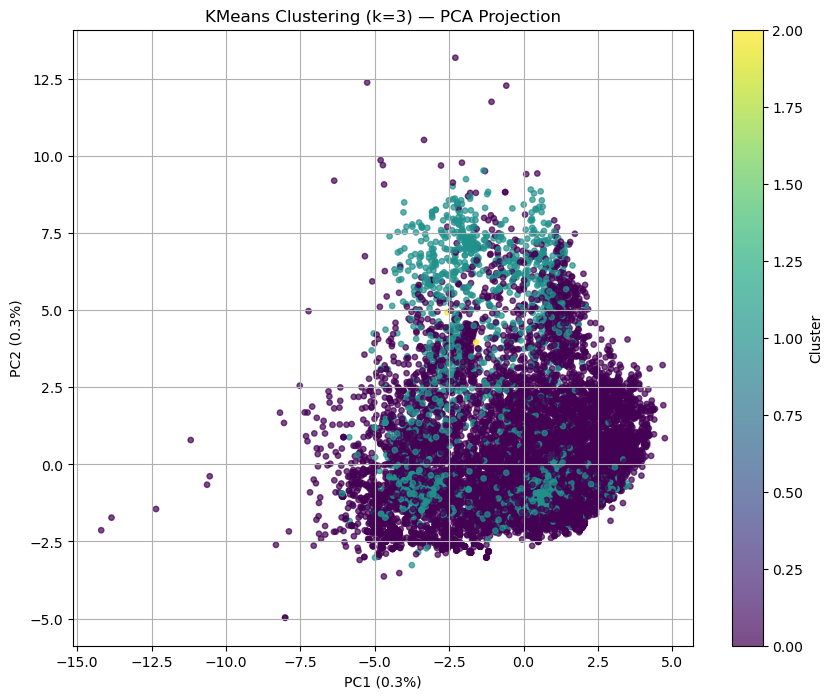

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Используем ранее подготовленную матрицу X_scaled
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Добавим метки кластеров в исходный датафрейм (если нужно)
X['Cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=15, alpha=0.7)
plt.title('KMeans Clustering (k=3) — PCA Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

Иерархический алгоритм

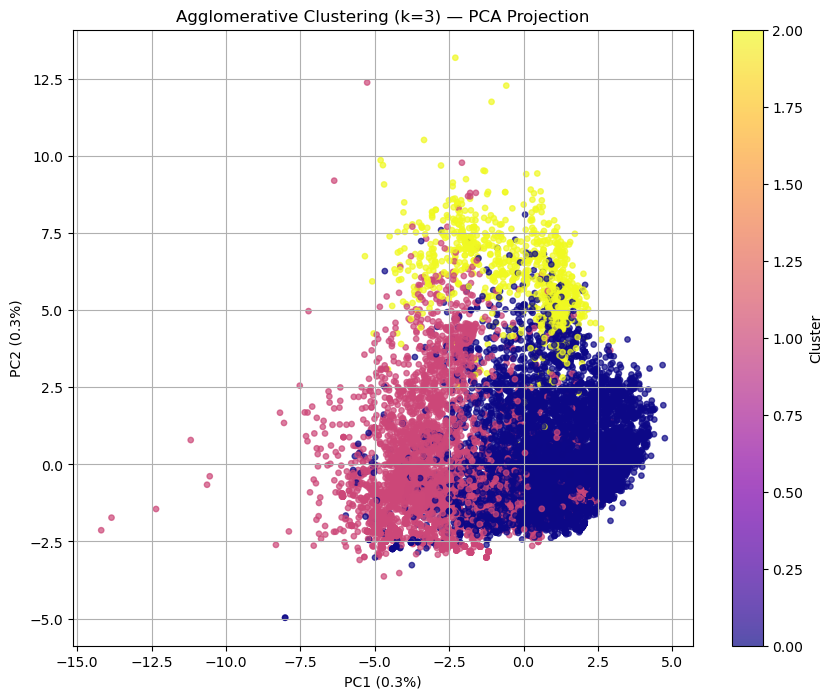

In [6]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Иерархическая кластеризация
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# Визуализация
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma', s=15, alpha=0.7)
plt.title('Agglomerative Clustering (k=3) — PCA Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

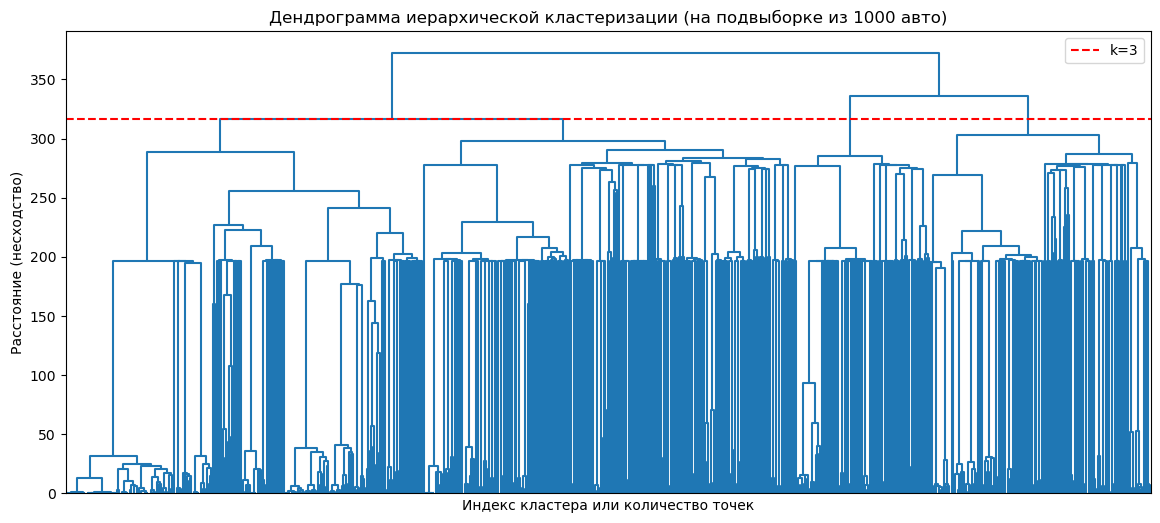

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=19000, replace=False)
X_sample = X_scaled[sample_idx]
linkage_matrix = linkage(X_sample, method='ward')

# Строим дендрограмму
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='level',  # показываем только последние уровни слияния
    p=10,                   # количество уровней для отображения
    no_labels=True,         # убираем подписи точек
    color_threshold=0       # чтобы все ветви были цветными
)
plt.title('Дендрограмма иерархической кластеризации (на подвыборке из 19000 авто)')
plt.xlabel('Индекс кластера или количество точек')
plt.ylabel('Расстояние (несходство)')
plt.axhline(y=linkage_matrix[-3, 2], color='red', linestyle='--', label='k=3')
plt.legend()
plt.show()

#### 5. Оценить качество решения
Точки плотно расположены на графиках, поэтому данные плохо разделяются на чёткие кластеры, это как раз видно по коэффициенту силуэта, он был отрицательным. Поэтому нельзя прям жёстко разделить рынок на типы, это означает: один автомобиль может соответствовать нескольким профилям. Выбросы — это потенциально интересные нишевые сегменты.

In [13]:
cars_original = pd.read_csv("car_price_prediction.csv", sep=",")
# cars_original — исходный датафрейм БЕЗ обработки
cars_original['KMeans_Cluster'] = cluster_labels
cars_original['Agg_Cluster'] = agg_labels

# Ключевые категориальные признаки
cat_cols = ['Category', 'Manufacturer', 'Fuel type', 'Leather interior', 'Gear box type']

print("=== Профили кластеров: KMeans ===")
for col in cat_cols:
    print(f"\n{col}:")
    print(cars_original.groupby('KMeans_Cluster')[col].apply(lambda x: x.mode()[0] if not x.mode().empty else '—'))

print("\n=== Профили кластеров: Agglomerative ===")
for col in cat_cols:
    print(f"\n{col}:")
    print(cars_original.groupby('Agg_Cluster')[col].apply(lambda x: x.mode()[0] if not x.mode().empty else '—'))

=== Профили кластеров: KMeans ===

Category:
KMeans_Cluster
0    Sedan
1     Jeep
2     Jeep
Name: Category, dtype: object

Manufacturer:
KMeans_Cluster
0     TOYOTA
1    HYUNDAI
2     NISSAN
Name: Manufacturer, dtype: object

Fuel type:
KMeans_Cluster
0    Petrol
1    Diesel
2    Diesel
Name: Fuel type, dtype: object

Leather interior:
KMeans_Cluster
0    Yes
1    Yes
2     No
Name: Leather interior, dtype: object

Gear box type:
KMeans_Cluster
0    Automatic
1    Automatic
2       Manual
Name: Gear box type, dtype: object

=== Профили кластеров: Agglomerative ===

Category:
Agg_Cluster
0       Sedan
1       Sedan
2    Microbus
Name: Category, dtype: object

Manufacturer:
Agg_Cluster
0          HYUNDAI
1    MERCEDES-BENZ
2             OPEL
Name: Manufacturer, dtype: object

Fuel type:
Agg_Cluster
0    Petrol
1    Petrol
2    Diesel
Name: Fuel type, dtype: object

Leather interior:
Agg_Cluster
0    Yes
1    Yes
2     No
Name: Leather interior, dtype: object

Gear box type:
Agg_Cluster


##### Вывод: 

1. KMeans даёт более логичную сегментацию по бизнес-цели.
- Кластер 0 (Sedan + TOYOTA + Petrol + Leather interior: Yes + Automatic).
Комфортный городской седан (надёжный, премиум-оснащённый, автомат). Больше похоже на профиль покупателя-городского автомобиля.
- Кластер 1 (Jeep + HYUNDAI + Diesel + Leather: Yes + Automatic). Полноценный внедорожник/кроссовер с кожаным салоном и автоматом — семейный или загородный профиль.
- Кластер 2 (Jeep + NISSAN + Diesel + Leather: No + Manual). Бюджетный внедорожник с механикой — профиль покупателя, ценящего проходимость и экономичность, возможно, такси или рабочий транспорт.

2. Agglomerative даёт менее интерпретируемую сегментацию
- Кластер 0 (Sedan + HYUNDAI + Petrol + Automatic + Leather: Yes). Похож на KMeans Кластер 0, но бренд другой.
- Кластер 1 (Sedan + MERCEDES-BENZ + Petrol + Automatic + Leather: Yes). Премиальный седан, но он отдельно от других седанов, возможно, из-за редкости бренда в датасете.
- Кластер 2 (Microbus + OPEL + Diesel + Manual + Leather: No). Коммерческий/нишевый сегмент (микроавтобусы), который сильно отличается от легковых авто.

KMeans оказался более эффективным для поставленной бизнес-задачи.
Несмотря на низкий коэффициент силуэта (что говорит о перекрытии кластеров в признаковом пространстве), он сформировал практически значимые и маркетингово полезные сегменты.

AgglomerativeClustering, хотя и технически корректен, дал менее сбалансированное разбиение, ориентированное на статистические особенности (редкие бренды, микроавтобусы), а не на потребительские профили.